# Five-fold baseline training

Open this notebook in VS Code and select your Colab GPU kernel. Run cells in order: install packages, locate the project and load `.env`, verify CUDA and frozen splits, then train. No Google Drive mount or archive is required.

The project must be visible to the selected kernel. If it is not, use VS Code Explorer → **Upload to Colab** for `roof_utils/`, `pyproject.toml`, `splits/`, `data/` and `data_preparation_outputs/`, preserving the project layout. Set `PROJECT_ROOT_OVERRIDE` to that runtime directory if automatic detection fails. Upload `.env` only if its paths suit the remote runtime; otherwise relative defaults are created.

Checkpoints and reports use the paths in `.env`. Colab runtime storage is temporary: download the model and report folders before deleting the runtime. Resume requires the previous checkpoints and reports with matching code/settings/software. Do not run the same experiment concurrently in two kernels.

Training results appear when you execute the notebook; no GPU results are precomputed.


After updating `roof_utils/cross_validation.py` on the remote runtime, restart the notebook kernel to clear old imports, then rerun from the beginning. These experiments use new run names; old checkpoints are not resumed.

In [1]:
# Run this before importing project modules. Preserve Colab's working CUDA stack.
import sys, subprocess, importlib.util
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'numpy>=1.24,<3', 'Pillow>=10,<13', 'matplotlib>=3.8,<4'])
if any(importlib.util.find_spec(name) is None for name in ('torch', 'torchvision')):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'torch==2.8.0', 'torchvision==0.23.0'])
# If pip requests a kernel restart, restart and rerun from here.


In [2]:
from pathlib import Path

roots = [
    p.parent for p in Path("/content").rglob("pyproject.toml")
    if (p.parent / "roof_utils").is_dir()
]
print(roots)

[PosixPath('/content')]


In [3]:
from pathlib import Path
import os
# Usually detected automatically; otherwise set this to the path visible to
# the selected kernel (e.g. /content/dida_test_task after Upload to Colab).
PROJECT_ROOT_OVERRIDE = os.environ.get('DIDA_PROJECT_ROOT', '')
candidates = ([Path(PROJECT_ROOT_OVERRIDE).expanduser()] if PROJECT_ROOT_OVERRIDE else
              [Path.cwd(), *Path.cwd().parents, Path('/content/dida_test_task')])
PROJECT_ROOT = next((p.resolve() for p in candidates
                     if (p / 'pyproject.toml').is_file() and (p / 'roof_utils').is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        f'Kernel working directory: {Path.cwd()}. Project is not visible here. '
        'In VS Code Explorer, use Upload to Colab for the project files, then '
        'set PROJECT_ROOT_OVERRIDE to their runtime path and rerun. Google Drive is not required.')
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--no-deps', '-e', str(PROJECT_ROOT)])
sys.path.insert(0, str(PROJECT_ROOT))
from roof_utils.config import load_paths
# Use the existing .env. Create relative defaults only if it is absent.
env_file = PROJECT_ROOT / '.env'
if not env_file.exists():
    env_file.write_text('RAW_DATA_DIR=data\nPREPARED_DATA_DIR=data_preparation_outputs\n'
                        'MODELS_DIR=models\nREPORTS_DIR=reports\n')
paths = load_paths(PROJECT_ROOT)
print('Kernel project root:', PROJECT_ROOT)
print('Models:', paths.models_dir)
print('Reports:', paths.reports_dir)
# Models/reports on a temporary Colab disk must be downloaded before the
# runtime is deleted. Resume requires retaining those files.


Kernel project root: /content
Models: /content/models
Reports: /content/reports


In [4]:
import torch, torchvision
from roof_utils.validation_splits import print_split_summary
from roof_utils.cross_validation import CVConfig, run_cross_validation, plot_history, show_predictions, compare_runs
print('PyTorch:', torch.__version__, '| torchvision:', torchvision.__version__)
assert torch.cuda.is_available(), 'Select the Colab GPU kernel before training.'
print('GPU:', torch.cuda.get_device_name(0))
print_split_summary(paths)


PyTorch: 2.11.0+cu128 | torchvision: 0.26.0+cu128
GPU: Tesla T4
Plan: v1 | Seed: 42
Scope: Fixed image-level development CV; geographic independence is NOT established. Not an independent final test.
Grouping: Singleton visual scene groups after inspection of 30 images and candidate-pair screening; no repeated building/scene confirmed. These IDs are not known geographic locations.
Excluded: {'278': 'quarantined', '535': 'unlabelled', '537': 'unlabelled', '539': 'unlabelled', '551': 'unlabelled', '553': 'unlabelled'}
Fold 0: train=20, validation=4, roof/valid=13.89%; IDs=121, 241, 328, 417
Fold 1: train=19, validation=5, roof/valid=16.76%; IDs=270, 301, 308, 314, 317
Fold 2: train=19, validation=5, roof/valid=15.31%; IDs=287, 320, 343, 345, 379
Fold 3: train=19, validation=5, roof/valid=15.56%; IDs=284, 300, 303, 315, 324
Fold 4: train=19, validation=5, roof/valid=13.56%; IDs=272, 274, 337, 381, 532
PASS: no split overlap; all 24 eligible images validate exactly once; groups intact; dat

## Experiment

U-Net / ImageNet ResNet18, 256×256 inputs, batch size 4, masked BCE + Dice. Decoder warm-up: 5 epochs at 1e-3; then encoder 1e-5 and decoder 1e-4. Encoder BatchNorm stays frozen. Up to 100 epochs, selecting the lowest full-fold validation BCE + Dice loss. Early stopping requires at least 30 completed epochs and 20 consecutive fine-tuning epochs without improvement. Patience can accrue before epoch 30. IoU remains reported at threshold 0.5; it does not select checkpoints. Fixed threshold 0.5.

Training uses flips, quarter-turn rotations and mild colour changes. Crop probability is zero for the baseline. Validation is never augmented. Image 278 remains excluded. Each of the 24 eligible images gets one saved out-of-fold prediction.

These are development CV scores: the validation folds also select the best epoch. Geographic independence is unverified. Do not present them as an untouched final-test result.

In [5]:
# from pathlib import Path
# import importlib
# import inspect
# import shutil
# import roof_utils.cross_validation as cv

# destination = Path(cv.__file__).resolve()
# print("Python currently imports:", destination)

# # Find uploaded copies containing the new settings.
# candidates = []
# for path in Path("/content").rglob("cross_validation*.py"):
#     text = path.read_text()
#     if "min_epochs:" in text and "monitor:" in text:
#         candidates.append(path)

# if not candidates:
#     raise FileNotFoundError(
#         "No updated copy found under /content. "
#         "Check that you uploaded to the SAME Colab server as this notebook."
#     )

# source = max(candidates, key=lambda p: p.stat().st_mtime)
# print("Updated file found at:", source)

# if source.resolve() != destination:
#     shutil.copy2(destination, destination.with_suffix(".py.bak"))
#     shutil.copy2(source, destination)

# # Remove cached bytecode, reload the module, and refresh imported names.
# cached = getattr(cv, "__cached__", None)
# if cached:
#     Path(cached).unlink(missing_ok=True)

# importlib.invalidate_caches()
# cv = importlib.reload(cv)

# CVConfig = cv.CVConfig
# run_cross_validation = cv.run_cross_validation
# plot_history = cv.plot_history
# show_predictions = cv.show_predictions
# compare_runs = cv.compare_runs

# assert "monitor" in inspect.signature(CVConfig).parameters
# print("SUCCESS: the updated runner is loaded.")

In [8]:
RUN_NAME = 'baseline_cv_loss_threshold045'
CONFIG = CVConfig(
    crop_probability=0.0, 
    threshold=0.45, 
    monitor="val_loss", 
    min_epochs=30, 
    patience=20,
    max_epochs=200,
)
FOLDS = [0, 1, 2, 3, 4]  # Use [0] to run one fold first; restore all five later.
print(CONFIG)


CVConfig(seed=42, max_epochs=200, warmup_epochs=5, patience=20, monitor='val_loss', min_epochs=30, threshold=0.45, batch_size=4, crop_probability=0.0, encoder_lr=1e-05, warmup_decoder_lr=0.001, decoder_lr=0.0001, weight_decay=0.0001)


In [ ]:
# import shutil

# # Deletes ALL folds, checkpoints, and reports for this RUN_NAME.
# # Leaves your dataset and other named experiments untouched.
# for folder in [
#     paths.models_dir / RUN_NAME,
#     paths.reports_dir / RUN_NAME,
# ]:
#     if folder.exists():
#         shutil.rmtree(folder)
#         print("Deleted:", folder)

Deleted: /content/models/baseline_cv_loss_threshold045
Deleted: /content/reports/baseline_cv_loss_threshold045


In [11]:
summary = run_cross_validation(paths, RUN_NAME, CONFIG, folds=FOLDS, device="cuda")

fold 0 | epoch   1 | val loss 0.6208 | val IoU 0.3233 | roof 17.75% | best val_loss 0.6208 (epoch 1)
fold 0 | epoch   2 | val loss 0.5532 | val IoU 0.4474 | roof 19.35% | best val_loss 0.5532 (epoch 2)
fold 0 | epoch   3 | val loss 0.5224 | val IoU 0.5013 | roof 19.07% | best val_loss 0.5224 (epoch 3)
fold 0 | epoch   4 | val loss 0.5183 | val IoU 0.4727 | roof 24.14% | best val_loss 0.5183 (epoch 4)
fold 0 | epoch   5 | val loss 0.4984 | val IoU 0.5176 | roof 19.38% | best val_loss 0.4984 (epoch 5)
fold 0 | epoch   6 | val loss 0.5009 | val IoU 0.5055 | roof 19.98% | best val_loss 0.4984 (epoch 5)
fold 0 | epoch   7 | val loss 0.5004 | val IoU 0.5080 | roof 20.36% | best val_loss 0.4984 (epoch 5)
fold 0 | epoch   8 | val loss 0.4951 | val IoU 0.5236 | roof 20.14% | best val_loss 0.4951 (epoch 8)
fold 0 | epoch   9 | val loss 0.4911 | val IoU 0.5338 | roof 20.06% | best val_loss 0.4911 (epoch 9)
fold 0 | epoch  10 | val loss 0.4864 | val IoU 0.5475 | roof 19.75% | best val_loss 0.4864 

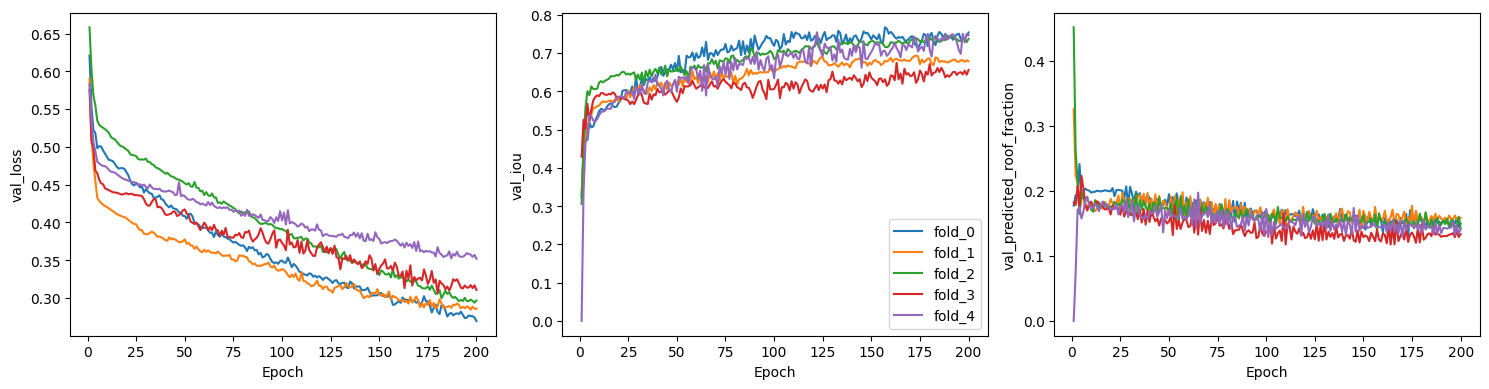

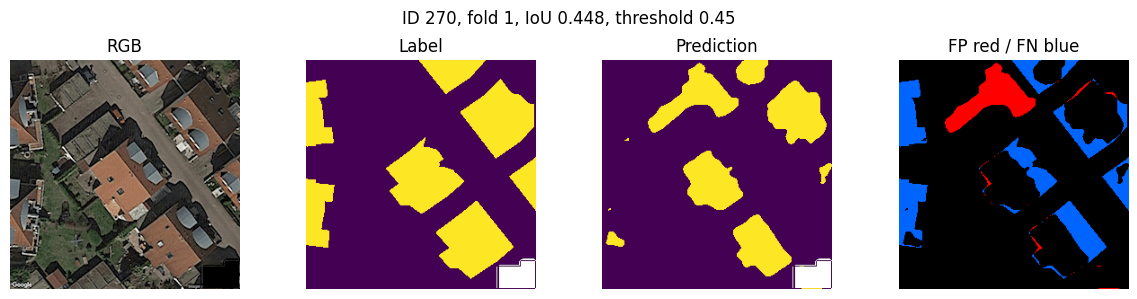

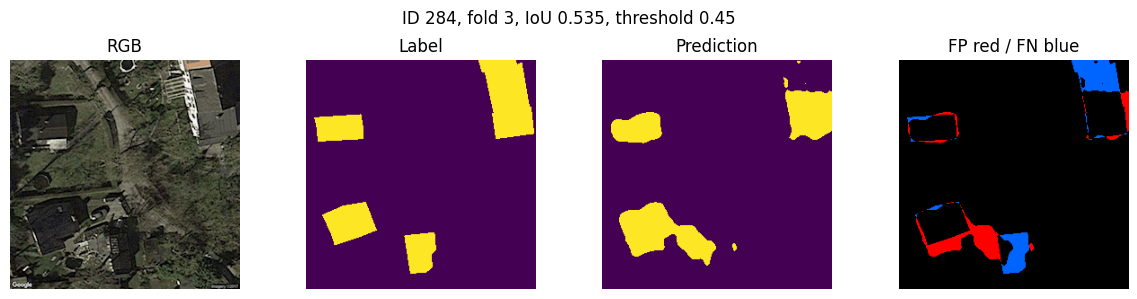

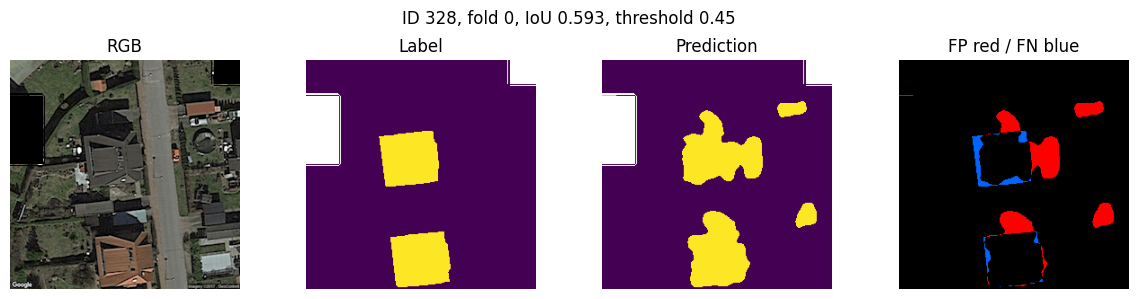

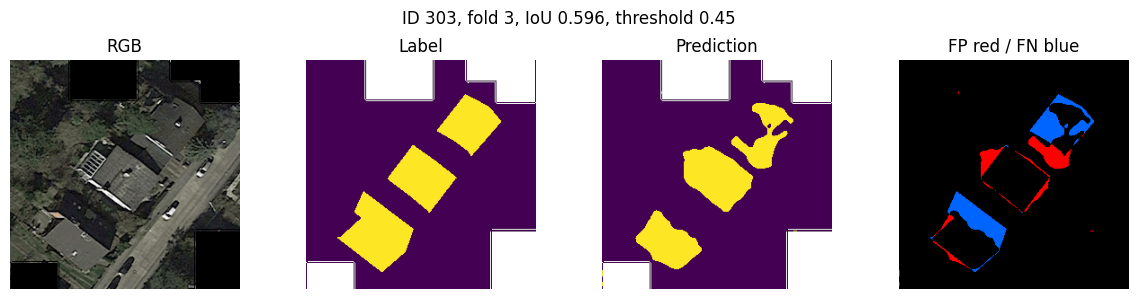

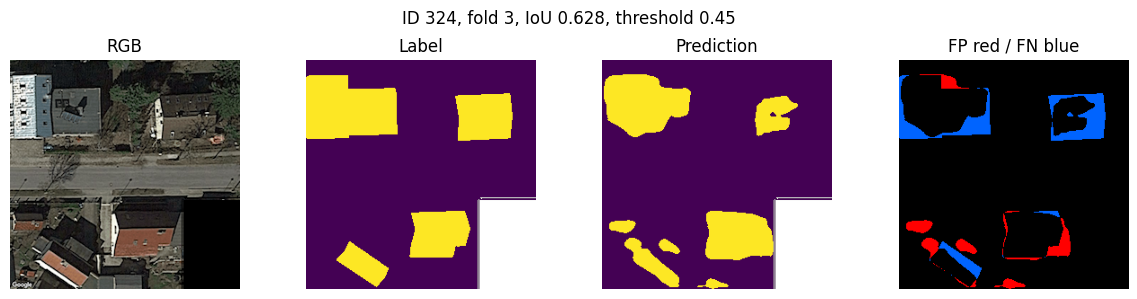

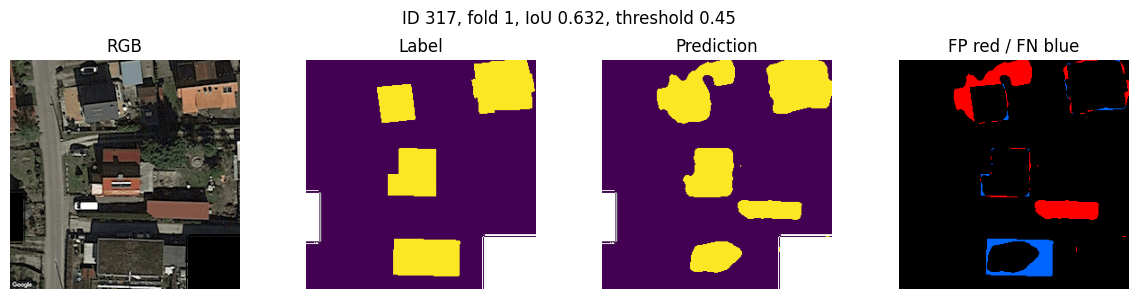

In [12]:
plot_history(paths, RUN_NAME)
show_predictions(paths, RUN_NAME, limit=6)